In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pytorch_lightning as pl
from datetime import datetime
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from torchmetrics import MeanAbsolutePercentageError
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

In [2]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

seaborn            : 0.13.2
torch              : 2.2.2
tensorflow         : 2.19.0
pytorch_forecasting: 1.4.0
numpy              : 1.26.4
pandas             : 2.2.2
matplotlib         : 3.9.2
pytorch_lightning  : 2.2.2
torchmetrics       : 1.7.4



In [3]:
'''!pip install torch==2.2.2 pytorch-lightning==2.2.2 pytorch-forecasting==1.4.0'''

'!pip install torch==2.2.2 pytorch-lightning==2.2.2 pytorch-forecasting==1.4.0'

In [4]:
seed = 777
torch.manual_seed(seed)

In [5]:
dados = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/Dados/Industria.csv', index_col = 0)

In [6]:
len(dados)

52416

In [7]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52416 entries, 1/1/23 0:00 to 12/30/23 23:50
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Indicador_MTTR   52416 non-null  float64
 1   Indicador_EME    52416 non-null  float64
 2   Indicador_ICE    52416 non-null  float64
 3   Indicador_ITMIE  52416 non-null  float64
 4   Indicador_IQMP   52416 non-null  float64
 5   Turno1           52416 non-null  float64
 6   Turno2           52416 non-null  float64
 7   Turno3           52416 non-null  float64
dtypes: float64(8)
memory usage: 3.6+ MB


In [8]:
dados.head()

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Turno1,Turno2,Turno3
Data,,,,,,,,
1/1/23 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1/1/23 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
1/1/23 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
1/1/23 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
1/1/23 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [9]:
dados.iloc[[0, -1]]

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Turno1,Turno2,Turno3
Data,,,,,,,,
1/1/23 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
12/30/23 23:50,6.580,74.1,0.081,0.062,0.111,28349.80989,24055.23167,13345.49820


In [10]:
dados.index = pd.to_datetime(dados.index)

In [11]:
len(dados)

52416

In [12]:
dados.head()

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Turno1,Turno2,Turno3
Data,,,,,,,,
2023-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2023-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2023-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2023-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2023-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [13]:
dados_hr = dados.resample('1h').mean()

In [14]:
dados_hr.head()

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Turno1,Turno2,Turno3
Data,,,,,,,,
2023-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,18026.747720,19252.048193
2023-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,16078.419453,17042.891567
2023-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,14330.699088,15676.144578
2023-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,13219.452887,14883.855422
2023-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,12921.580547,14317.108433


In [15]:
dados_hr.shape

(8736, 8)

In [16]:
dados_hr.isnull().sum()

Indicador_MTTR     0
Indicador_EME      0
Indicador_ICE      0
Indicador_ITMIE    0
Indicador_IQMP     0
Turno1             0
Turno2             0
Turno3             0
dtype: int64

In [17]:

dados_hr.describe()

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Turno1,Turno2,Turno3
count,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.807624,15.475739,2.340551,260.820277,119.691920,7068.919876,5165.178202,6591.013989
min,3.602167,12.710000,0.054667,0.019000,0.040000,14329.113923,8685.947047,6190.636254
25%,14.403750,58.324583,0.078167,0.064000,0.124167,26292.951730,17016.901716,13148.470246
50%,18.759167,69.815833,0.085500,9.947417,8.241250,32342.303347,20787.229493,16427.659642
75%,22.866667,81.350000,4.915333,326.487500,105.883333,37318.002218,24677.609019,21598.447824
max,39.695000,94.750000,5.933667,953.350000,861.000000,51844.261932,36254.699050,47223.765690


In [18]:
df_turno1 = dados_hr.drop(['Turno2', 'Turno3'], axis=1)
df_turno2 = dados_hr.drop(['Turno1', 'Turno3'], axis=1)
df_turno3 = dados_hr.drop(['Turno1', 'Turno2'], axis=1)

In [19]:
df1 = df_turno1.rename(columns = {'Turno1': 'Demanda_Insumos'})
df1['Turno'] = 'Turno 1'
x1 = range(1, 8737, 1)
df1['idx'] = x1
df1.head()

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Demanda_Insumos,Turno,idx
Data,,,,,,,,
2023-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,Turno 1,1
2023-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,Turno 1,2
2023-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,Turno 1,3
2023-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,Turno 1,4
2023-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,Turno 1,5


In [20]:
df2 = df_turno2.rename(columns = {'Turno2': 'Demanda_Insumos'})
df2['Turno'] = 'Turno 2'
x2 = range(1, 8737, 1)
df2['idx'] = x2
df2.head()

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Demanda_Insumos,Turno,idx
Data,,,,,,,,
2023-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,18026.747720,Turno 2,1
2023-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,16078.419453,Turno 2,2
2023-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,14330.699088,Turno 2,3
2023-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,13219.452887,Turno 2,4
2023-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,12921.580547,Turno 2,5


In [21]:
df3 = df_turno3.rename(columns = {'Turno3': 'Demanda_Insumos'})
df3['Turno'] = 'Turno 3'
x3 = range(1, 8737, 1)
df3['idx'] = x3
df3.head()

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Demanda_Insumos,Turno,idx
Data,,,,,,,,
2023-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,19252.048193,Turno 3,1
2023-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,17042.891567,Turno 3,2
2023-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,15676.144578,Turno 3,3
2023-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,14883.855422,Turno 3,4
2023-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,14317.108433,Turno 3,5


In [22]:
df_concat = pd.concat([df1, df2, df3])

In [23]:
df_concat.head()

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Demanda_Insumos,Turno,idx
Data,,,,,,,,
2023-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,Turno 1,1
2023-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,Turno 1,2
2023-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,Turno 1,3
2023-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,Turno 1,4
2023-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,Turno 1,5


In [24]:
df_concat.tail()

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Demanda_Insumos,Turno,idx
Data,,,,,,,,
2023-12-30 19:00:00,9.453333,62.406667,0.074667,0.052000,0.102000,16926.770708,Turno 3,8732
2023-12-30 20:00:00,9.041667,63.990000,0.080333,0.052667,0.105000,16998.799520,Turno 3,8733
2023-12-30 21:00:00,8.011667,69.675000,0.081500,0.073167,0.098333,16608.883553,Turno 3,8734
2023-12-30 22:00:00,7.598333,70.315000,0.081833,0.058667,0.108167,15614.885955,Turno 3,8735
2023-12-30 23:00:00,6.877500,72.900000,0.081500,0.060333,0.092667,14143.577428,Turno 3,8736


In [25]:
df_concat.query('idx==1')

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Demanda_Insumos,Turno,idx
Data,,,,,,,,
2023-01-01,6.196833,75.066667,0.081833,0.0635,0.098833,29197.974683,Turno 1,1
2023-01-01,6.196833,75.066667,0.081833,0.0635,0.098833,18026.747720,Turno 2,1
2023-01-01,6.196833,75.066667,0.081833,0.0635,0.098833,19252.048193,Turno 3,1


In [26]:
df_concat.query('idx==2')

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Demanda_Insumos,Turno,idx
Data,,,,,,,,
2023-01-01 01:00:00,5.548833,77.583333,0.082,0.056833,0.1125,24657.215190,Turno 1,2
2023-01-01 01:00:00,5.548833,77.583333,0.082,0.056833,0.1125,16078.419453,Turno 2,2
2023-01-01 01:00:00,5.548833,77.583333,0.082,0.056833,0.1125,17042.891567,Turno 3,2


In [27]:
date = df_concat.index
df_concat['Hora'] = date.hour
df_concat['Dia_Semana'] = date.dayofweek
df_concat['Mes'] = date.month

In [28]:
df_concat.head()

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Demanda_Insumos,Turno,idx,Hora,Dia_Semana,Mes
Data,,,,,,,,,,,
2023-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,Turno 1,1,0,6,1
2023-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,Turno 1,2,1,6,1
2023-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,Turno 1,3,2,6,1
2023-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,Turno 1,4,3,6,1
2023-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,Turno 1,5,4,6,1


In [29]:
df_final = df_concat.reset_index(drop = True)

In [30]:
df_final

,Indicador_MTTR,Indicador_EME,Indicador_ICE,Indicador_ITMIE,Indicador_IQMP,Demanda_Insumos,Turno,idx,Hora,Dia_Semana,Mes
0,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,Turno 1,1,0,6,1
1,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,Turno 1,2,1,6,1
2,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,Turno 1,3,2,6,1
3,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,Turno 1,4,3,6,1
4,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,Turno 1,5,4,6,1
...,...,...,...,...,...,...,...,...,...,...,...
26203,9.453333,62.406667,0.074667,0.052000,0.102000,16926.770708,Turno 3,8732,19,5,12
26204,9.041667,63.990000,0.080333,0.052667,0.105000,16998.799520,Turno 3,8733,20,5,12
26205,8.011667,69.675000,0.081500,0.073167,0.098333,16608.883553,Turno 3,8734,21,5,12
26206,7.598333,70.315000,0.081833,0.058667,0.108167,15614.885955,Turno 3,8735,22,5,12


Text(0.5, 1.0, 'Demanda de Insumos (em Litros) Por Hora e Por Turno no Mês 9')

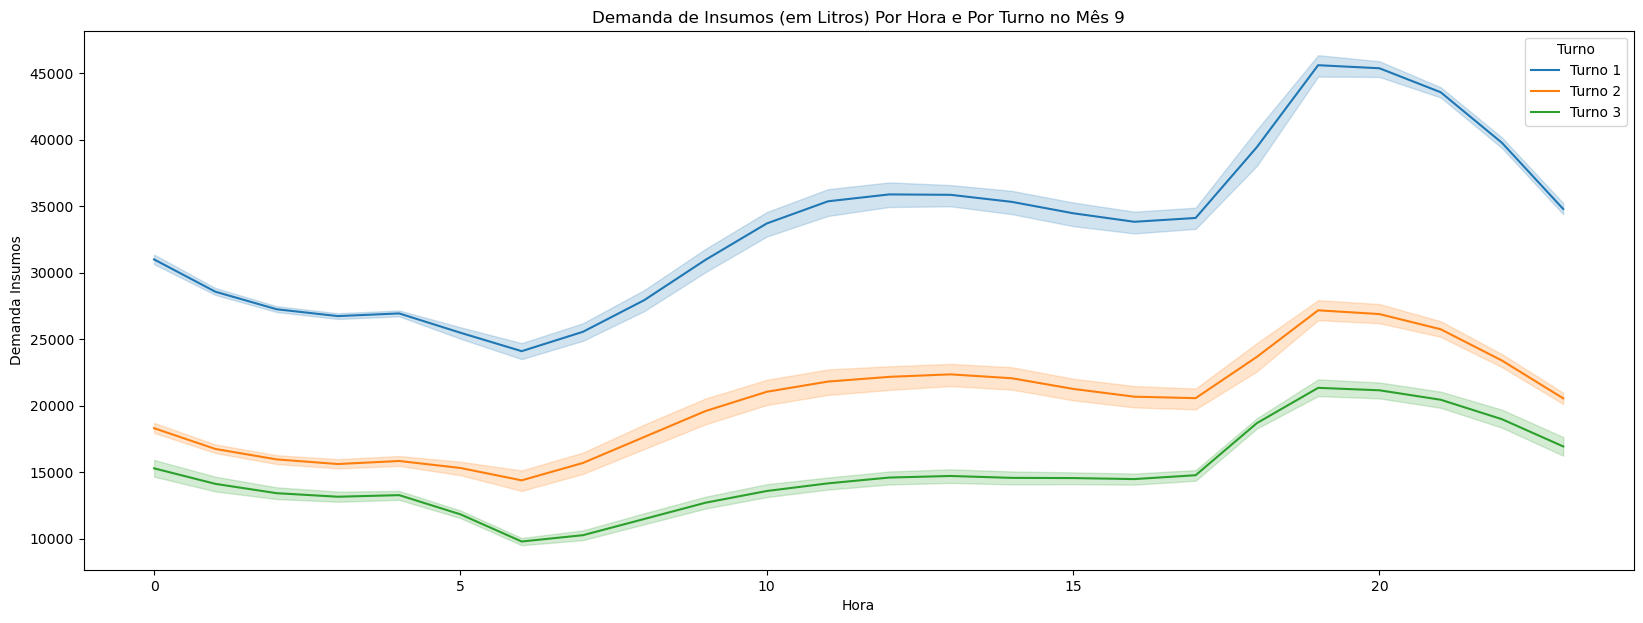

In [31]:
fig, ax = plt.subplots(figsize = (20, 7))
sns.lineplot(data = df_final[df_final['Mes'] == 9], x = 'Hora', y = 'Demanda_Insumos', hue = 'Turno', legend = 'full')
ax.set_xlabel('Hora')
ax.set_ylabel('Demanda Insumos')
ax.tick_params(axis = 'both', which = 'major', labelsize = 10)
ax.set_title(label = 'Demanda de Insumos (em Litros) Por Hora e Por Turno no Mês 9' )

In [32]:
df_final[['Turno', 'Demanda_Insumos']].groupby('Turno').mean()

,Demanda_Insumos
Turno,
Turno 1,32344.970564
Turno 2,21042.509082
Turno 3,17835.406218


In [33]:
corr = df_final.drop('Turno', axis=1).corr()
power_corr = pd.DataFrame(corr['Demanda_Insumos'].sort_values(ascending = False))
print(power_corr)

                 Demanda_Insumos
Demanda_Insumos         1.000000
Hora                    0.437560
Indicador_MTTR          0.314332
Indicador_ICE           0.143296
Indicador_ITMIE         0.098014
Indicador_IQMP          0.023550
idx                     0.004838
Mes                     0.002954
Dia_Semana             -0.041322
Indicador_EME          -0.193188


In [34]:
corr_idx = df_final.drop('Turno', axis=1).corr().sort_values('Demanda_Insumos', ascending = False).index
corr_sorted = df_final.loc[:, corr_idx]

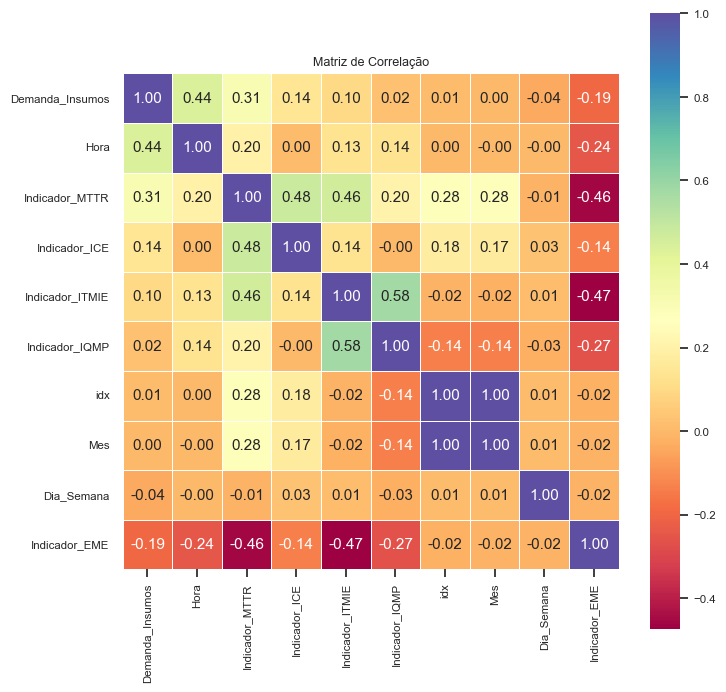

In [35]:
plt.figure(figsize = (8,8))
sns.set(font_scale = 0.75)
ax = sns.heatmap(corr_sorted.corr().round(3),
                 annot = True,
                 square = True,
                 linewidths = .70,
                 cmap = 'Spectral',
                 fmt = '.2f',
                 annot_kws = {'size': 11})
ax.xaxis.tick_bottom()
plt.title("Matriz de Correlação")
plt.show()

In [36]:
lookback = 24 * 7

In [37]:
janela_previsao = 24

In [38]:
indice_divisao = df_final['idx'].max() - janela_previsao

In [39]:
indice_divisao

8712

In [40]:
dados_treino = TimeSeriesDataSet(

    df_final[lambda x: x.idx <= indice_divisao],
    time_idx = 'idx',
    target = 'Demanda_Insumos',
    group_ids = ['Turno'],
    min_encoder_length = lookback //2,
    max_encoder_length = lookback,
    min_prediction_length = 1,
    max_prediction_length = janela_previsao,
    static_categoricals = ['Turno'],

    time_varying_known_reals = ['idx',
                                'Hora',
                                'Indicador_MTTR',
                                'Indicador_EME',
                                'Indicador_ICE',
                                'Indicador_ITMIE'],

time_varying_unknown_reals = ['Demanda_Insumos'],
target_normalizer = GroupNormalizer(
    groups = ['Turno'],
    transformation = 'softplus'),

    add_relative_time_idx = True,
    add_target_scales = True,
    add_encoder_length = True

)

In [41]:
type(dados_treino)

pytorch_forecasting.data.timeseries._timeseries.TimeSeriesDataSet

In [42]:
print(dados_treino)

TimeSeriesDataSet[length=26205](
	time_idx='idx',
	target='Demanda_Insumos',
	group_ids=['Turno'],
	weight=None,
	max_encoder_length=168,
	min_encoder_length=84,
	min_prediction_idx=1,
	min_prediction_length=1,
	max_prediction_length=24,
	static_categoricals=['Turno'],
	static_reals=None,
	time_varying_known_categoricals=None,
	time_varying_known_reals=['idx', 'Hora', 'Indicador_MTTR', 'Indicador_EME', 'Indicador_ICE', 'Indicador_ITMIE'],
	time_varying_unknown_categoricals=None,
	time_varying_unknown_reals=['Demanda_Insumos'],
	variable_groups=None,
	constant_fill_strategy=None,
	allow_missing_timesteps=False,
	lags=None,
	add_relative_time_idx=True,
	add_target_scales=True,
	add_encoder_length=True,
	target_normalizer=GroupNormalizer(
	method='standard',
	groups=['Turno'],
	center=True,
	scale_by_group=False,
	transformation='softplus',
	method_kwargs={}
),
	categorical_encoders={'__group_id__Turno': NaNLabelEncoder(add_nan=False, warn=True), 'Turno': NaNLabelEncoder(add_nan=False, wa

In [43]:
dados_valid = TimeSeriesDataSet.from_dataset(dados_treino,
                                             df_final,
                                             predict = True,
                                             stop_randomization = True)

In [44]:
dl_treino = dados_treino.to_dataloader(train = True, batch_size = 32, num_workers = 2)

In [45]:
dl_valid = dados_valid.to_dataloader(train = False, batch_size = 32, num_workers =2)

In [46]:
early_stop_callback = EarlyStopping(monitor = 'val_loss',
                                    min_delta = 1e-4,
                                    patience = 5,
                                    verbose = True,
                                    mode = 'min')

In [47]:
lr_logger = LearningRateMonitor()

In [48]:
epochs = 20

In [49]:
trainer = pl.Trainer(
    max_epochs = epochs,
    devices = 1,
    accelerator = 'cpu',
    enable_model_summary = True,
    gradient_clip_val = 0.1,
    callbacks = [lr_logger, early_stop_callback],
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [50]:
modelo = TemporalFusionTransformer.from_dataset(
    dados_treino,
    learning_rate=0.001,
    hidden_size=128,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=128,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=4
)

print(type(modelo))

<class 'pytorch_forecasting.models.temporal_fusion_transformer._tft.TemporalFusionTransformer'>


In [51]:
torch.set_float32_matmul_precision('high')

In [52]:
trainer.fit(modelo, train_dataloaders=dl_treino, val_dataloaders=dl_valid)

TypeError: `model` must be a `LightningModule` or `torch._dynamo.OptimizedModule`, got `TemporalFusionTransformer`